In [1]:
%run functions.ipynb

import os

os.makedirs("../submission", exist_ok=True)

df = load_data()
df.head()

,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [2]:
# Remove trend and yearly cycle: z_t = (1 - B)(1 - B^12) y_t
df = remove_trend_and_cycle(df)
plot_time_series(df.dropna(), yt_col="yt_true_d1d12")

<Figure size 1200x400 with 1 Axes>

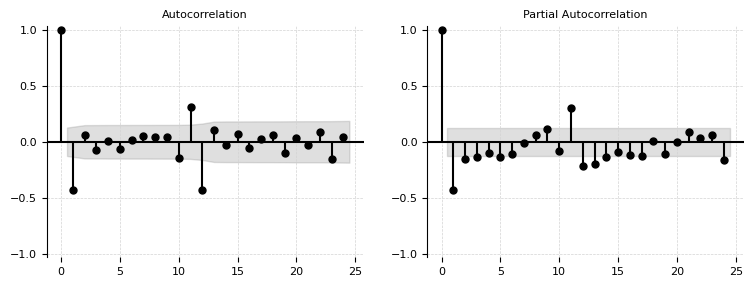

In [3]:
acf_pacf_plots(df.yt_true_d1d12.dropna())

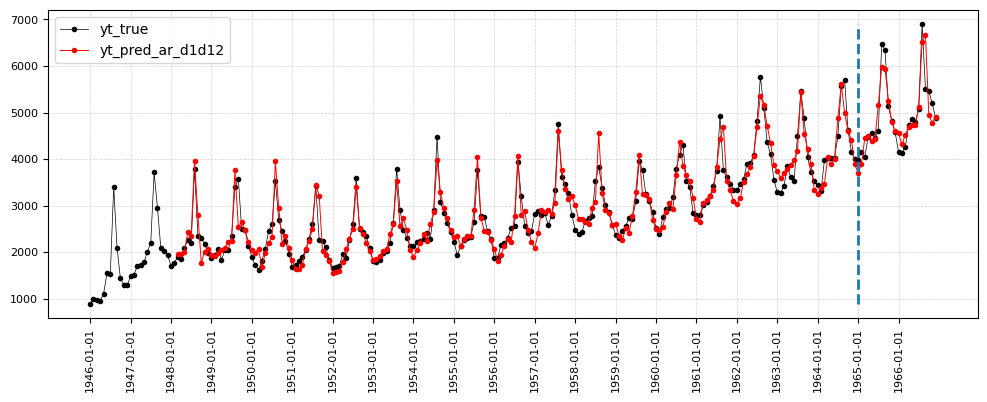

In [4]:
# Model 5: linear AR(13) over the differenced series
from sklearn.linear_model import LinearRegression

P = 13
df = make_lagged_ts(df, P, "yt_true_d1d12")
x_columns = [f"lagged_{i}m" for i in range(1, P + 1)]

data = df.dropna()
X_complete, y_complete, X_train, y_train, X_test, y_test = train_test_split(
    data, x_columns, "yt_true_d1d12"
)
model = LinearRegression().fit(X_train, y_train)

# Undo the differencing: y_t = z_t + y_{t-1} + y_{t-12} - y_{t-13}
z_pred = pd.Series(np.nan, index=df.index)
z_pred[data.index] = model.predict(X_complete)
df["yt_pred_ar_d1d12"] = (
    z_pred + df.yt_true.shift(1) + df.yt_true.shift(12) - df.yt_true.shift(13)
)
plot_time_series(df[["yt_true", "yt_pred_ar_d1d12"]])

In [5]:
metrics = compute_evaluation_metrics(df[["yt_true", "yt_pred_ar_d1d12"]].dropna())
save_forecasts(df)
save_metrics(metrics)
metrics

,Metrics,yt_pred_ar_d1d12
0,MSE Train,66646.65
1,MSE Test,138815.45
2,MAE Train,188.42
3,MAE Test,267.05
